# MULTI-STORE RETAIL SALE ANALYSIS

**Import Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Customer Id,Store Name,Transaction Date,Aisle,Product Name,Quantity,Unit Price,Total Amount,Discount Amount,Final Amount,Loyalty Points
0,2610,Corner Grocery,2023-11-23,Frozen Foods,Ice Cream,3,59.37,178.11,25.38,152.73,15
1,2521,SuperSave Central,2024-11-09,Frozen Foods,Frozen Pizza,4,47.85,191.40,38.97,152.43,15
2,2718,FamilyFood Express,2023-04-15,Health & Wellness,Multivitamins,2,109.14,218.28,61.05,157.23,15
3,2820,FreshMart Downtown,2023-12-14,Health & Wellness,Protein Bar,2,95.04,190.08,21.02,169.06,16
4,1821,MegaMart Westside,2023-09-16,Canned Goods,Corn,4,15.82,63.28,17.60,45.68,4


**Data Understanding**

In [3]:
df.shape


(59542, 11)

In [4]:
df.nunique()


Customer Id          2172
Store Name              9
Transaction Date     1097
Aisle                   7
Product Name           23
Quantity               40
Unit Price          10085
Total Amount        18734
Discount Amount      6526
Final Amount        19222
Loyalty Points         59
dtype: int64

In [5]:
df.describe()


,Customer Id,Quantity,Unit Price,Total Amount,Discount Amount,Final Amount,Loyalty Points
count,59542.000000,59542.000000,58433.000000,59542.000000,59542.000000,59542.000000,59542.000000
mean,2135.472927,2.347267,40.480099,90.233340,13.535686,75.202224,7.171778
std,641.807417,2.731296,24.876863,83.558176,16.413752,73.469952,7.193955
min,1000.000000,-5.000000,5.500000,4.168289,0.000000,-470.530000,0.000000
25%,1567.000000,1.000000,22.400000,34.870000,3.470000,28.830000,2.000000
50%,2157.000000,2.000000,34.480000,63.640000,8.040000,53.050000,5.000000
75%,2681.000000,3.000000,49.400000,114.020000,17.260000,96.007500,9.000000
max,3258.000000,49.000000,119.990000,599.200000,176.010000,586.370000,58.000000


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59542 entries, 0 to 59541
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer Id       59542 non-null  int64  
 1   Store Name        58405 non-null  object 
 2   Transaction Date  59542 non-null  object 
 3   Aisle             59542 non-null  object 
 4   Product Name      59542 non-null  object 
 5   Quantity          59542 non-null  int64  
 6   Unit Price        58433 non-null  float64
 7   Total Amount      59542 non-null  float64
 8   Discount Amount   59542 non-null  float64
 9   Final Amount      59542 non-null  float64
 10  Loyalty Points    59542 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 5.0+ MB


**Data Cleaning**

*Cleaning col names*

In [7]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.columns


Index(['customer_id', 'store_name', 'transaction_date', 'aisle',
       'product_name', 'quantity', 'unit_price', 'total_amount',
       'discount_amount', 'final_amount', 'loyalty_points'],
      dtype='object')

*Handling Missing Values*


In [8]:
df.isnull().sum()


customer_id            0
store_name          1137
transaction_date       0
aisle                  0
product_name           0
quantity               0
unit_price          1109
total_amount           0
discount_amount        0
final_amount           0
loyalty_points         0
dtype: int64

In [9]:
# mode for each customer_id
df['store_name'] = df.groupby('customer_id')['store_name'].transform(lambda x: x.fillna(x.mode()[0] 
if not x.mode().empty else 'Unknown'))


In [10]:
df['store_name'].value_counts()


store_name
SuperSave Central      7423
Corner Grocery         7411
FamilyFood Express     7410
MegaMart Westside      7399
GreenGrocer Plaza      7395
QuickStop Market       7341
FreshMart Downtown     7300
ValuePlus Market       7269
Fresh Mart Downtown     594
Name: count, dtype: int64

In [11]:
# using mean in place of null values
df['unit_price'].fillna(df['unit_price'].mean(), inplace= True)


In [12]:
df['unit_price'].isnull().sum()


0

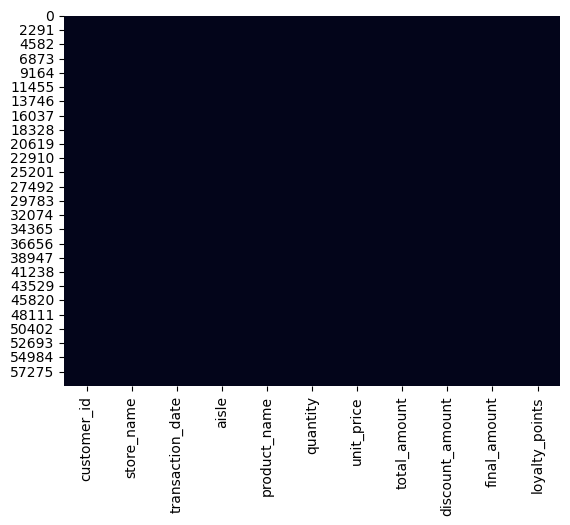

In [ ]:
# Visualizing null Value
sns.heatmap(df.isnull(), cbar=False)
plt.show()


*Handling Duplicates*

In [14]:
df.duplicated().sum()


590

In [15]:
df = df.drop_duplicates()


*Date and time Datatype*

In [16]:
df['transaction_date'].head()


0    2023-11-23
1    2024-11-09
2    2023-04-15
3    2023-12-14
4    2023-09-16
Name: transaction_date, dtype: object

In [17]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)


In [18]:
df['transaction_date'].min()


Timestamp('2023-01-01 00:00:00')

In [19]:
df['transaction_date'].max()


Timestamp('2027-01-01 00:00:00')

*Feature Engineering*

In [20]:
# Adding Year Column
df["year"] = df["transaction_date"].dt.year


In [21]:
df["year"].value_counts()


year
2025    19699
2023    19498
2024    19455
2027      300
Name: count, dtype: int64

In [22]:
df = df[df["year"] <= 2025]
df["year"].unique()


array([2023, 2024, 2025])

In [23]:
# Adding month Column
df["month"] = df["transaction_date"].dt.month


In [24]:
# Adding Day of Week
df["day_name"] = df["transaction_date"].dt.day_name()


*Financial Validation*

In [25]:
(df['quantity'] * df['unit_price'] - df['total_amount']).sum()


274571.7508247973

In [26]:
(df['total_amount'] - df['discount_amount'] - df['final_amount']).sum()


88811.18284008383

*Checking negative values in numeric columns*

In [27]:
(df[['quantity',
     'unit_price',
     'total_amount',
     'discount_amount',
     'final_amount']] < 0).sum()


quantity           580
unit_price           0
total_amount         0
discount_amount      0
final_amount       583
dtype: int64

In [28]:
df = df[
    (df["quantity"] > 0) ]


In [29]:
(df['quantity']<0).sum()


0

*Validating Calculations*

In [30]:
df["total_amount"] = (
    df["quantity"] * df["unit_price"]
)

df["final_amount"] = (
    df["total_amount"] - df["discount_amount"]
)


In [31]:
df.shape


(58072, 14)

**Outlier Detection**

*Finding Outlier*

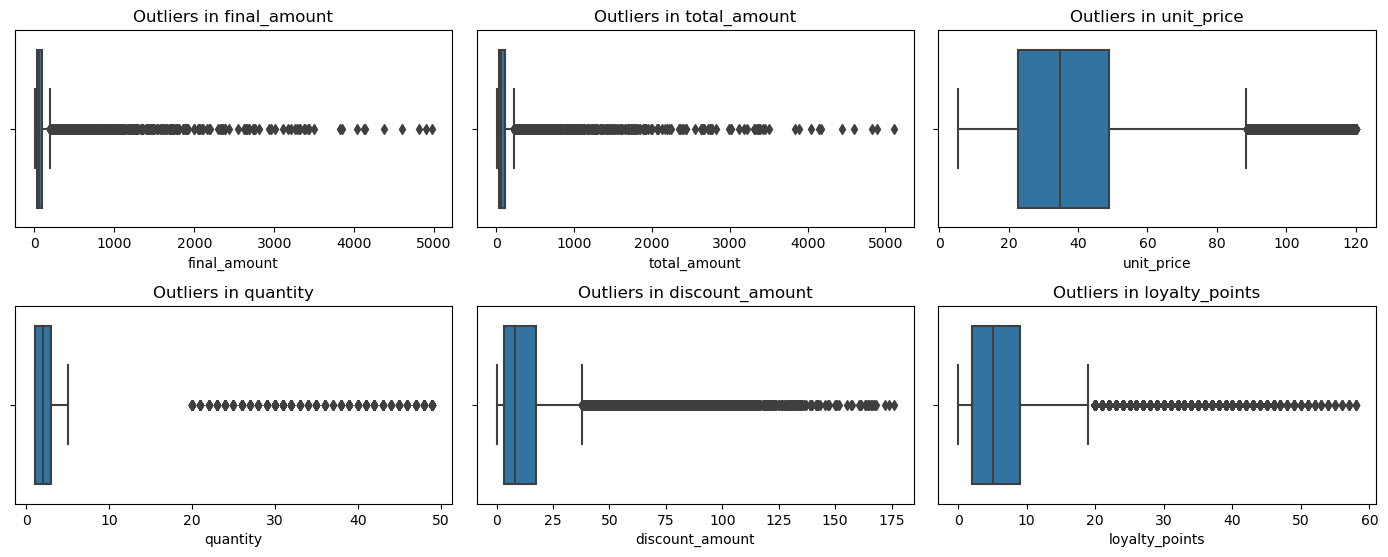

In [32]:
plt.figure(figsize=(14,8))

columns = [
    "final_amount",
    "total_amount",
    "unit_price",
    "quantity",
    "discount_amount",
    "loyalty_points"
]

for i, col in enumerate(columns, 1):

    plt.subplot(3, 3, i)

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Outliers in {col}")

plt.tight_layout()

plt.show()


In [33]:
columns = [
    "final_amount",
    "total_amount",
    "unit_price",
    "quantity",
    "discount_amount",
    "loyalty_points"
]
for i, col in enumerate(columns, 1):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]
    
    print(col, "outliers:", count)


final_amount outliers: 3889
total_amount outliers: 3780
unit_price outliers: 4207
quantity outliers: 296
discount_amount outliers: 4190
loyalty_points outliers: 3715


*Removing Extreame to outlier*

In [ ]:
upper_limit = df["final_amount"].quantile(0.99)

df = df[
    df["final_amount"] <= upper_limit
]


**Exploratory Data Analysis (EDA)**

*Univariant Analysis*

Text(0.5, 1.0, 'Quantity Distribution')

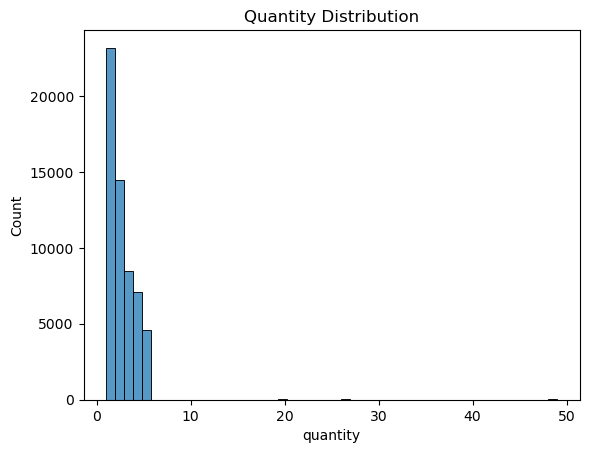

In [35]:
# Product Quantity Distribution
sns.histplot(df['quantity'], bins=50)
plt.title("Quantity Distribution")


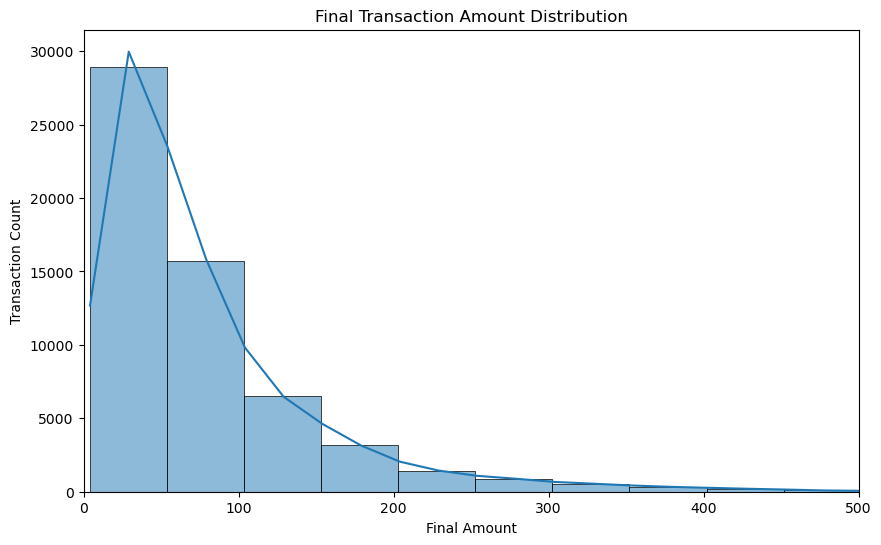

In [36]:
# Final Transaction Anount Distribution
plt.figure(figsize=(10,6))
sns.histplot(
    df["final_amount"],
    bins=100,
    kde=True
)
plt.xlim(0, 500)
plt.title("Final Transaction Amount Distribution")
plt.xlabel("Final Amount")
plt.ylabel("Transaction Count")
plt.show()


Text(0.5, 1.0, 'Aisles Frequency')

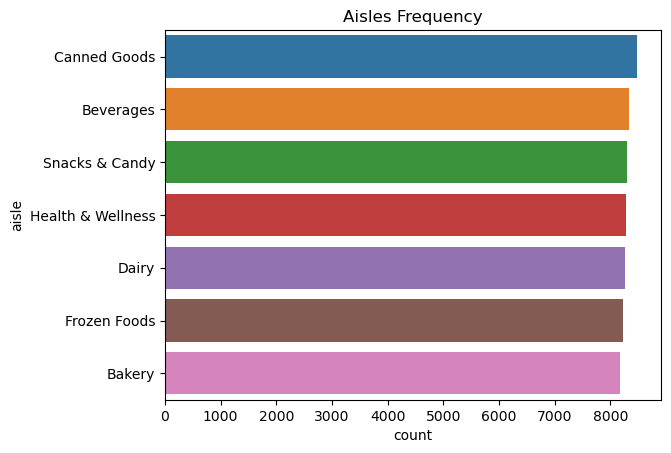

In [37]:
# Top Aisles Frequency
sns.countplot(
    y=df['aisle'],
    order=df['aisle'].value_counts().index[:10],
)
plt.title("Aisles Frequency")


*Bivariant Analysis*

Text(0, 0.5, 'Final Amount')

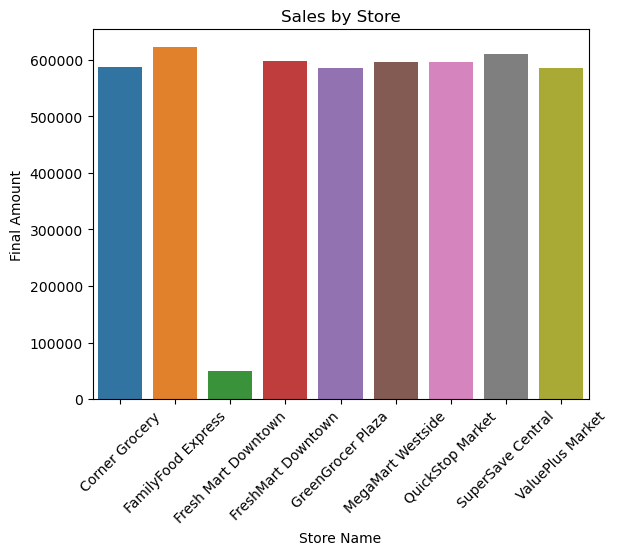

In [39]:
# Sales by Store
store_sales = df.groupby('store_name')['final_amount'].sum().reset_index()

sns.barplot(
    data=store_sales,
    x='store_name',
    y='final_amount'
)
plt.xticks(rotation=45)
plt.title("Sales by Store")
plt.xlabel("Store Name")
plt.ylabel("Final Amount")


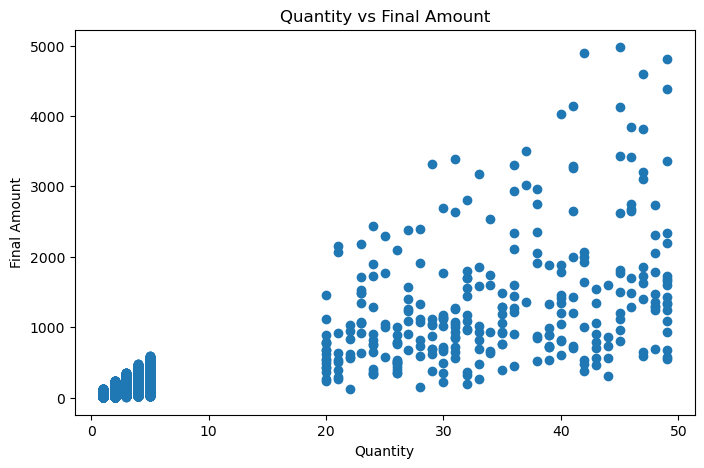

In [40]:
# Scatter Graph for Final amt
plt.figure(figsize=(8,5))
plt.scatter(
    df["quantity"],
    df["final_amount"]
)
plt.title("Quantity vs Final Amount")
plt.xlabel("Quantity")
plt.ylabel("Final Amount")
plt.show()


*Multivariant Analysis*

Text(50.722222222222214, 0.5, 'Month')

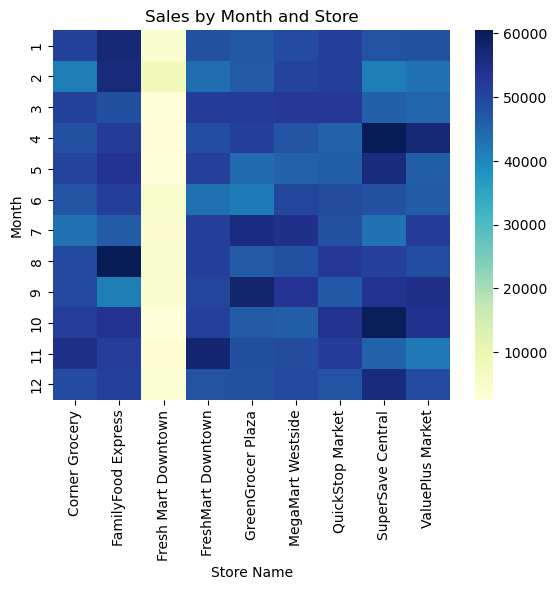

In [41]:
# Sales by Month & Store
pivot = df.pivot_table(
    values='final_amount',
    index='month',
    columns='store_name',
    aggfunc='sum'
)
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Sales by Month and Store")
plt.xlabel("Store Name")
plt.ylabel("Month")


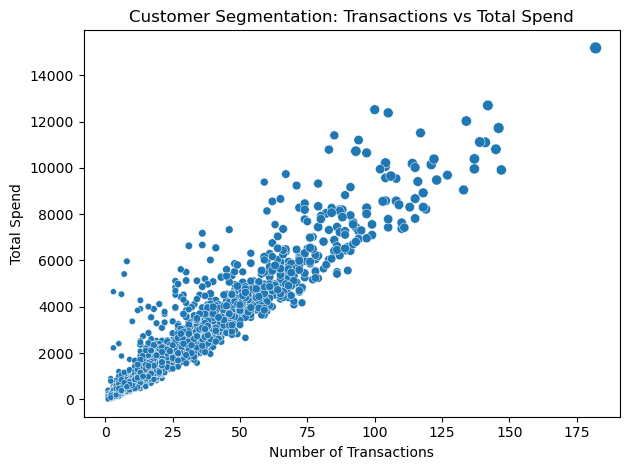

In [42]:
# Customer Segmentation
customer_summary = df.groupby('customer_id').agg({
    'final_amount': 'sum',
    'transaction_date': 'count',
    'loyalty_points': 'sum'
}).reset_index()

sns.scatterplot(
    data=customer_summary,
    x='transaction_date',
    y='final_amount',
    size='loyalty_points',
    legend=False   # removes legend
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Customer Segmentation: Transactions vs Total Spend")
plt.tight_layout()
plt.show()


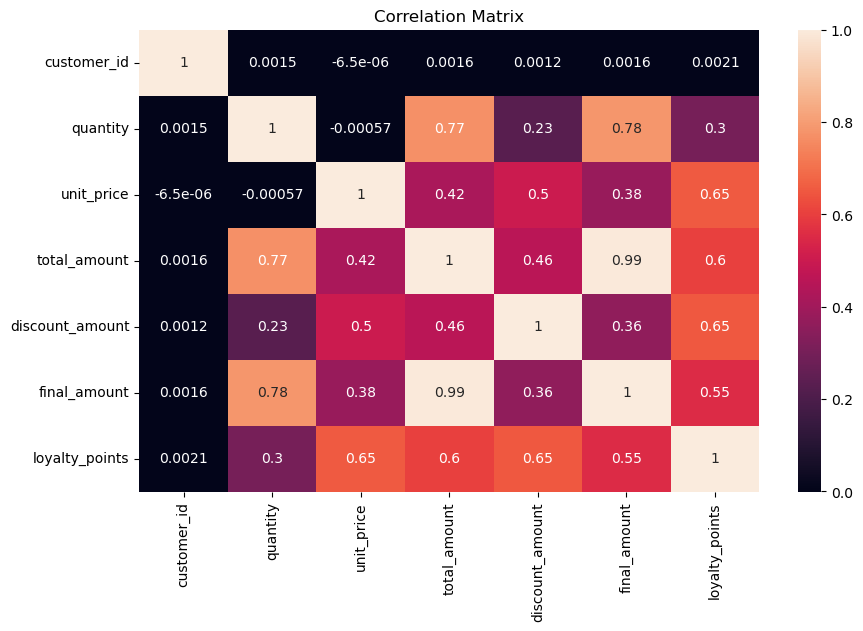

In [43]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.title("Correlation Matrix")
plt.show()


DATA SUMMARY

In [44]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.describe()


Rows: 58072
Columns: 14


,customer_id,transaction_date,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points,year,month
count,58072.000000,58072,58072.000000,58072.000000,58072.000000,58072.000000,58072.000000,58072.000000,58072.000000,58072.000000
mean,2135.319707,2024-07-02 14:15:27.896404224,2.391669,40.466888,96.745301,13.528243,83.217058,7.172389,2024.002962,6.524246
min,1000.000000,2023-01-01 00:00:00,1.000000,5.500000,5.570000,0.000000,4.120000,0.000000,2023.000000,1.000000
25%,1567.000000,2023-09-30 00:00:00,1.000000,22.660000,35.350000,3.460000,29.690000,2.000000,2023.000000,4.000000
50%,2157.000000,2024-07-01 00:00:00,2.000000,34.890000,64.460000,8.050000,54.160000,5.000000,2024.000000,7.000000
75%,2681.000000,2025-04-06 00:00:00,3.000000,49.010000,115.800000,17.280000,98.190000,9.000000,2025.000000,10.000000
max,3258.000000,2025-12-31 00:00:00,49.000000,119.990000,5109.750000,176.010000,4975.610000,58.000000,2025.000000,12.000000
std,642.004882,NaN,2.700908,24.621478,140.136101,16.382558,133.409719,7.192334,0.817566,3.443315


*Save Cleaned dataset*

In [ ]:
df.to_csv(
    "retail_clean.csv",
    index=False
)
